In [1]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

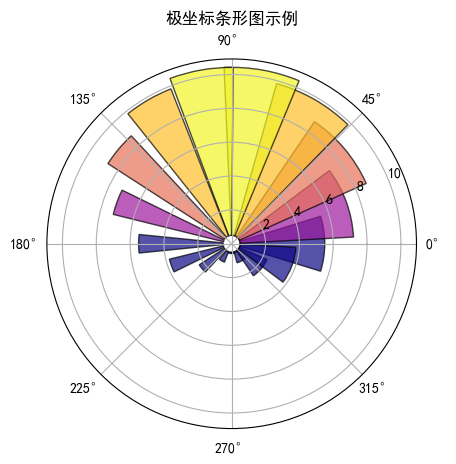

In [5]:
# 设置随机种子以确保结果可重现
np.random.seed(20240917)

# 计算饼图的扇区
N = 18  # 扇区的数量
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
radii = 5 + 5 * np.sin(theta)  # 使用正弦函数生成radii数据
width = 0.4 + 0.2 * np.cos(theta)  # 使用余弦函数生成条形宽度
colors = plt.cm.plasma((radii - 5) / 5)  # 使用 'plasma' 颜色映射，并调整范围

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# 绘制极坐标条形图
bars = ax.bar(theta, radii, width=width, bottom=0.5, color=colors, edgecolor='black', alpha=0.7)

# 添加条形图的边界
for bar in bars:
    bar.set_edgecolor('black')

# 设置图形标题
ax.set_title("极坐标条形图示例", va='bottom')

plt.show()


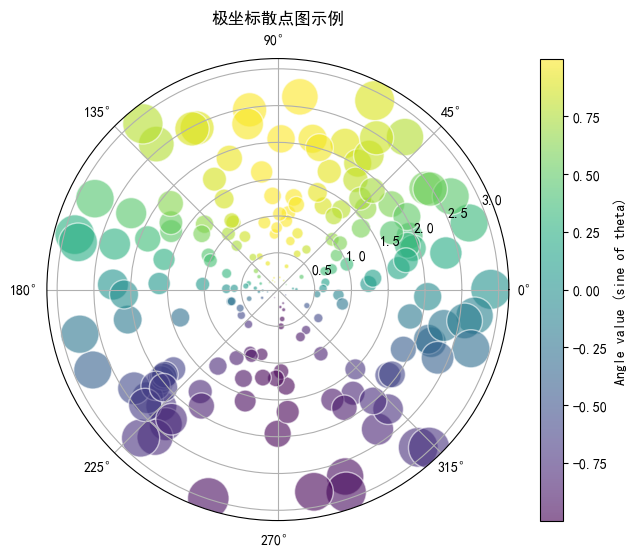

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以确保结果可重现
np.random.seed(20240917)

# 生成数据
N = 200  # 数据点数量
r = 3 * np.random.rand(N)  # 半径范围
theta = 2 * np.pi * np.random.rand(N)  # 角度数据
area = 100 * r**2  # 面积计算方式
colors = np.sin(theta)  # 使用正弦函数生成颜色数据

# 创建图形对象和极坐标子图
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='polar')

# 绘制极坐标散点图
sc = ax.scatter(theta, r, c=colors, s=area, cmap='viridis', alpha=0.6, edgecolors='w')

# 添加颜色条以显示颜色映射
cbar = plt.colorbar(sc, ax=ax, label='Color scale')
cbar.set_label('Angle value (sine of theta)')

# 设置标题
ax.set_title('极坐标散点图示例', va='bottom')

plt.show()


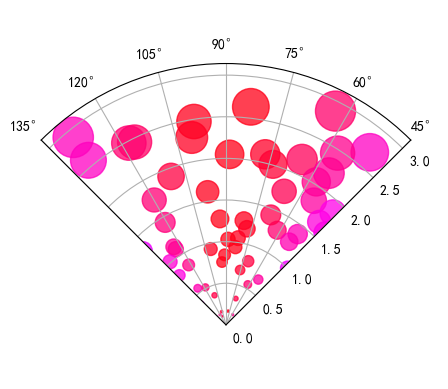

In [9]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(theta, r, c=colors, s=area, cmap='hsv', alpha=0.75)

ax.set_thetamin(45)
ax.set_thetamax(135)

plt.show()

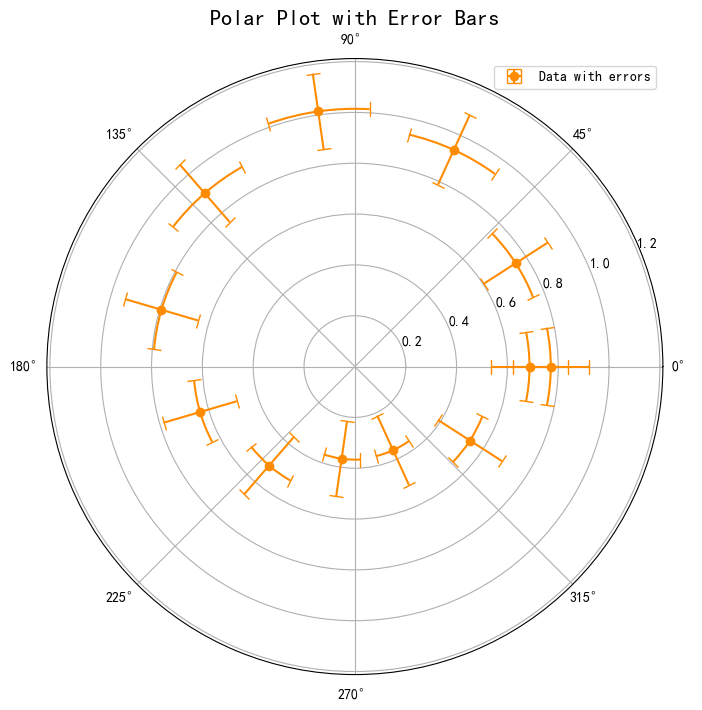

In [11]:
# 生成角度数据 theta，范围从 0 到 2*pi，以步长 pi/6 分割
theta = np.linspace(0, 2 * np.pi, 12)

# 创建半径数据 r，基于角度 theta 来生成，并增加一些随机扰动来模拟实际情况
r = 0.3 * np.sin(theta) + 0.7 + np.random.normal(0, 0.05, len(theta))

# 设置图形大小
fig = plt.figure(figsize=(8, 8))

# 创建一个极坐标子图
ax = fig.add_subplot(projection='polar')

# 绘制带有误差条的极坐标散点图，误差条的横向和纵向误差设置为常量
ax.errorbar(theta, r, xerr=0.2, yerr=0.15, fmt="o", capsize=5, color="darkorange", label="Data with errors")

# 添加标题，描述图形内容
ax.set_title("Polar Plot with Error Bars", fontsize=16)

# 添加图例
ax.legend(loc="upper right")

# 展示图形
plt.show()

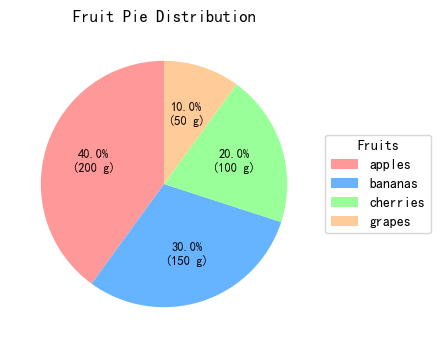

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 设置图形大小，并保持饼图为正方形
fig, ax = plt.subplots(figsize=(7, 4), subplot_kw=dict(aspect="equal"))

# 定义食谱数据，代表不同的水果及其重量
recipe = ["200 g apples", "150 g bananas", "100 g cherries", "50 g grapes"]

# 提取数据部分，即水果的重量
data = [int(x.split()[0]) for x in recipe]

# 提取水果名称，只提取字符串最后一个词，即水果名称，不包含重量单位
ingredients = [x.split()[2] for x in recipe]  # 提取水果名称部分，不包括单位 g

# 自定义函数，用于在饼图上显示百分比和对应的实际重量
def percentage_label(pct, allvals):
    # 计算绝对重量并将其显示在图表中
    absolute = int(np.round(pct / 100. * np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute} g)"  # 显示百分比和重量

# 生成饼图，使用自定义标签函数显示数据
wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: percentage_label(pct, data), 
                                  startangle=90,  # 从90度开始绘制饼图
                                  colors=["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"],  # 设定不同的颜色
                                  textprops=dict(color="black"))  # 修改文字为黑色

# 添加图例，显示各个水果和对应的扇区颜色
ax.legend(wedges, ingredients, 
          title="Fruits",  # 图例标题
          loc="center left",  # 图例位置
          bbox_to_anchor=(1, 0, 0.5, 1))  # 图例放置在图形的右侧

# 设置自动文本的字体大小和粗细
plt.setp(autotexts, size=9, weight="bold")

# 为饼图添加标题
ax.set_title("Fruit Pie Distribution")

# 显示图形
plt.show()

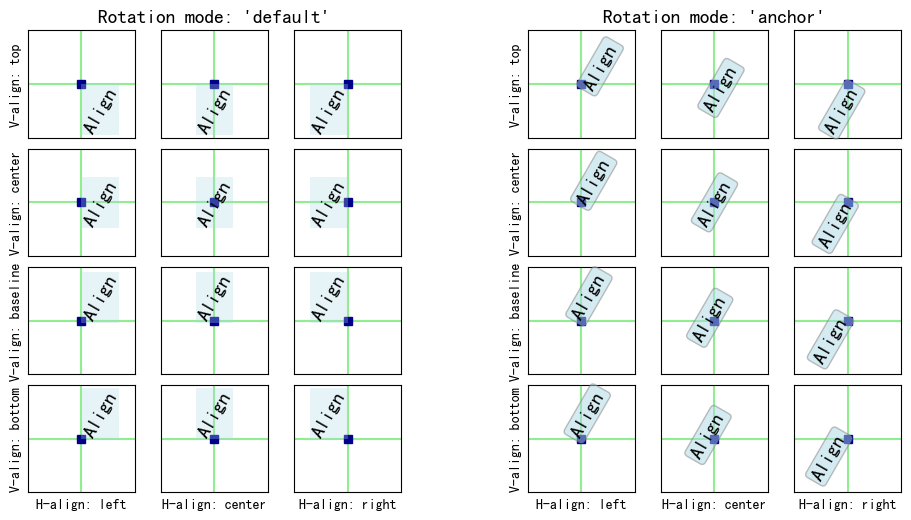

In [21]:
import matplotlib.pyplot as plt

# 自定义函数，测试不同的旋转模式
def custom_rotation_mode(fig, mode):
    # 水平对齐方式和垂直对齐方式
    ha_list = ["left", "center", "right"]
    va_list = ["top", "center", "baseline", "bottom"]

    # 创建子图，并调整网格布局
    axs = fig.subplots(len(va_list), len(ha_list), sharex=True, sharey=True,
                       subplot_kw=dict(aspect=1),
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))  # 增加子图间距

    # 设置子图的 x 轴和 y 轴标签
    for ha, ax in zip(ha_list, axs[-1, :]):
        ax.set_xlabel(f"H-align: {ha}", fontsize=10)  # 修改标签文字
    for va, ax in zip(va_list, axs[:, 0]):
        ax.set_ylabel(f"V-align: {va}", fontsize=10)  # 修改标签文字

    # 添加标题，展示不同的旋转模式
    axs[0, 1].set_title(f"Rotation mode: '{mode}'", fontsize=14)

    # 配置文本边框样式，根据模式不同调整
    text_box_config = (
        {} if mode == "default" else
        {"bbox": dict(boxstyle="round,pad=0.2", ec="gray", fc="lightblue", alpha=0.5)}
    )

    # 创建一个存储文本对象的字典
    texts = {}

    # 在每个子图中使用不同的对齐方式显示文本
    for i, va in enumerate(va_list):
        for j, ha in enumerate(ha_list):
            ax = axs[i, j]
            # 设置每个子图的刻度线为空
            ax.set(xticks=[], yticks=[])
            # 绘制参考线，便于观察对齐效果
            ax.axvline(0.5, color="lightgreen", zorder=0)  # 垂直参考线
            ax.axhline(0.5, color="lightgreen", zorder=0)  # 水平参考线
            ax.plot(0.5, 0.5, color="darkblue", marker="s", zorder=1)  # 中心点
            
            # 添加旋转的文本，改变旋转角度为 60 度，替换原来的 "Tpg" 文本
            tx = ax.text(0.5, 0.5, "Align",
                         size="x-large", rotation=60,  # 更改旋转角度
                         horizontalalignment=ha, verticalalignment=va,
                         rotation_mode=mode, **text_box_config)
            texts[ax] = tx

    # 如果使用默认模式，绘制文字框的边界
    if mode == "default":
        fig.canvas.draw()
        for ax, text in texts.items():
            bb = text.get_window_extent().transformed(ax.transData.inverted())
            rect = plt.Rectangle((bb.x0, bb.y0), bb.width, bb.height,
                                 facecolor="lightblue", alpha=0.3, zorder=2)
            ax.add_patch(rect)

# 创建主图形，并增加子图布局
fig = plt.figure(figsize=(10, 6))  # 调整图形大小

# 使用 subfigures 生成两个子图，分别显示不同的旋转模式
subfigs = fig.subfigures(1, 2)
custom_rotation_mode(subfigs[0], "default")  # 左侧子图使用默认模式
custom_rotation_mode(subfigs[1], "anchor")  # 右侧子图使用锚点模式

# 显示图形
plt.show()


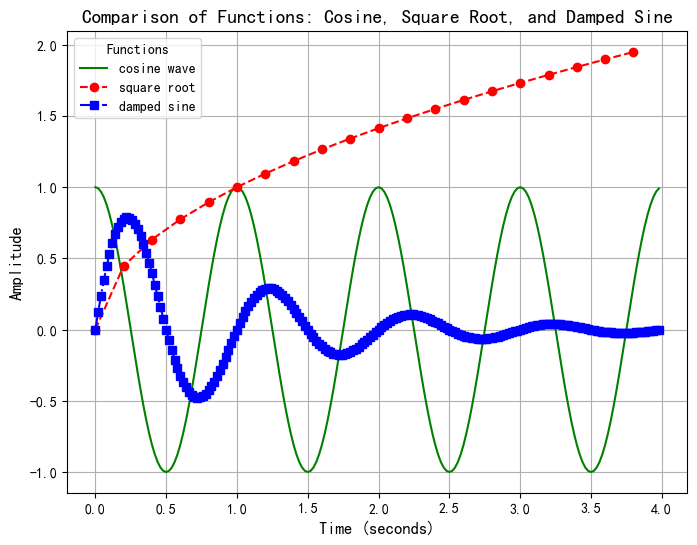

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 生成时间序列，使用不同的步长
t1 = np.arange(0.0, 4.0, 0.2)  # 步长大
t2 = np.arange(0.0, 4.0, 0.02)  # 步长小

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制三条不同的函数曲线
l1, = ax.plot(t2, np.cos(2 * np.pi * t2), 'g-', label="cosine wave")  # 使用余弦函数
l2, = ax.plot(t1, np.sqrt(t1), 'r--', marker='o', label="square root")  # 使用平方根函数，带有圆形标记
l3, = ax.plot(t2, np.sin(2 * np.pi * t2) * np.exp(-t2), 'b-.', marker='s', label="damped sine")  # 衰减正弦函数

# 设置图例，放置在左上角，使用不同的外观样式
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=False, title="Functions")

# 设置坐标轴标签
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)

# 设置图形标题
ax.set_title('Comparison of Functions: Cosine, Square Root, and Damped Sine', fontsize=14)

# 显示图形
plt.grid(True)  # 显示网格以便更好地观察
plt.show()


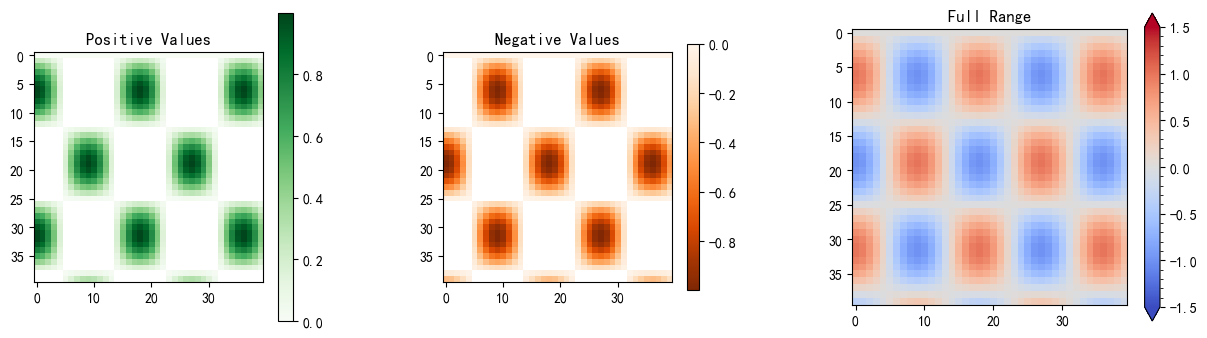

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 设置数据的大小
grid_size = 40

# 生成网格数据
x, y = np.mgrid[:grid_size, :grid_size]

# 创建数据集，使用正弦和余弦组合函数
Z = np.sin(x * 0.25) * np.cos(y * 0.35)

# 将数据分为正负两部分，并对正值和负值进行掩码
Z_positive = np.ma.masked_less(Z, 0)  # 仅保留大于0的部分
Z_negative = np.ma.masked_greater(Z, 0)  # 仅保留小于0的部分

# 创建一个包含三个子图的图形，调整布局
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), gridspec_kw={'width_ratios': [1, 1, 1.2]})

# 第一个子图：显示正值数据
positive_plot = ax1.imshow(Z_positive, cmap='Greens', interpolation='nearest')
fig.colorbar(positive_plot, ax=ax1, orientation='vertical', pad=0.05)  # 为第一个子图添加颜色条
ax1.set_title("Positive Values", fontsize=12)

# 第二个子图：显示负值数据
negative_plot = ax2.imshow(Z_negative, cmap='Oranges_r', interpolation='nearest')
fig.colorbar(negative_plot, ax=ax2, orientation='vertical', pad=0.05, shrink=0.8)  # 设置颜色条位置和缩放
ax2.set_title("Negative Values", fontsize=12)

# 第三个子图：显示正负混合数据，并设置显示范围
full_range_plot = ax3.imshow(Z, cmap='coolwarm', vmin=-1.5, vmax=1.5, interpolation='nearest')
colorbar = fig.colorbar(full_range_plot, ax=ax3, extend='both', orientation='vertical', pad=0.05)
colorbar.minorticks_on()  # 为颜色条添加细小刻度
ax3.set_title("Full Range", fontsize=12)

# 调整子图之间的间距
plt.subplots_adjust(wspace=0.4)

# 显示图形
plt.show()
